# IMPORTS ET CONFIGURATION


In [13]:
# ============================================================================
# IMPORTS ET CONFIGURATION
# ============================================================================
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')


# Configuration des chemins et onfiguration des graphiques

In [14]:
# Configuration des chemins
#project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Ajout des chemins Python
#sys.path.append(project_root)

# Configuration des graphiques
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

print("Configuration initiale terminée")
#print(f"Répertoire projet: {project_root}")



Configuration initiale terminée


# CHARGEMENT DE VOS DONNÉES SIPAKMED

In [15]:
current_dir = os.getcwd()  # Notebook est dans le répertoire courant
project_root = os.path.dirname(current_dir)
DATA_PATH = os.path.join(project_root, "data", "processed") + "/"

sys.path.append(os.path.join(project_root, "data"))
from data_loading import DataLoader

print("\n" + "="*60)
print("CHARGEMENT DU DATASET SIPAKMED")
print("="*60)


loader = DataLoader(
        path=DATA_PATH,
        augment=True,
        batch_size=32,
        target_size=(224, 224)
    )
    
train_gen, test_gen = loader.get_generators()
CLASS_NAMES = loader.get_class_names()
summary = loader.get_summary()


CHARGEMENT DU DATASET SIPAKMED
Vérification des données à: c:\Users\sarah\Documents\M Info\M2 SID\AASD\Apprentisaage\data\processed/
Données déjà présentes localement
Found 551 images belonging to 3 classes.
Found 551 images belonging to 3 classes.
Found 177 images belonging to 3 classes.
DataLoader initialisé:
   - Classes: ['Abnormal', 'Benign', 'Normal']
   - Batch size: 32
   - Image size: (224, 224)
   - Augmentation: Activée


# EXTRACTION D'IMAGES DE TEST



EXTRACTION D'IMAGES DE TEST
3 images extraites


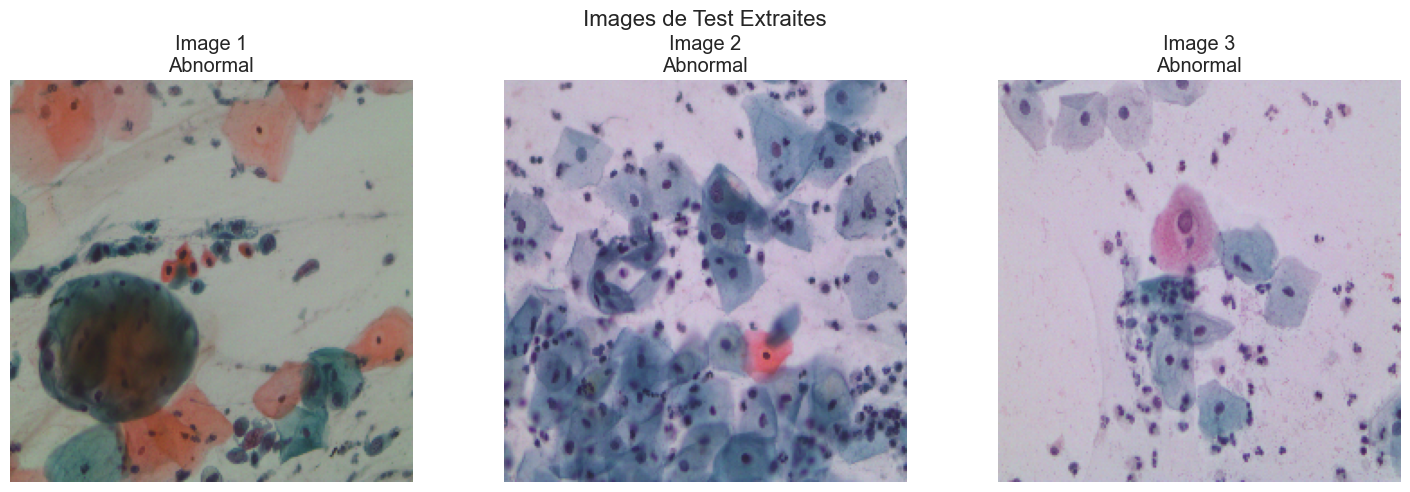

In [16]:
# ============================================================================
# EXTRACTION D'IMAGES DE TEST
# ============================================================================
print("\n" + "=" * 60)
print("EXTRACTION D'IMAGES DE TEST")
print("=" * 60)

def extract_test_samples_simple(test_gen, class_names, n_samples=5):
    """Extraire des images du test set - version simple et robuste
    
    Args:
        test_gen: Test data generator
        class_names: List of class names
        n_samples: Number of samples to extract
    """
    test_images = []
    test_labels = []
    true_classes = []
    
    # Réinitialiser le générateur
    test_gen.reset()
    
    # Nombre total d'échantillons dans le test set
    total_samples = test_gen.samples
    
    # Pour éviter une boucle infinie, utilisons un compteur de sécurité
    safety_counter = 0
    max_attempts = min(n_samples * 2, total_samples)  # Limite de sécurité
    
    while len(test_images) < n_samples and safety_counter < max_attempts:
        try:
            # Obtenir le prochain batch (batch_size=1 pour test_gen)
            img_batch, label_batch = next(test_gen)
            
            # Récupérer l'image et le label
            test_images.append(img_batch[0])  # Enlever la dimension batch
            test_labels.append(label_batch[0])
            
            # Récupérer la vraie classe
            true_class = np.argmax(label_batch[0])
            true_classes.append(true_class)
            
        except StopIteration:
            # Si on arrive à la fin du générateur, le réinitialiser
            test_gen.reset()
        except Exception as e:
            print(f"Erreur extraction image: {e}")
            # Créer une image de test factice
            dummy_img = np.random.rand(224, 224, 3).astype(np.float32)
            dummy_label = np.eye(len(class_names))[0]  # Première classe par défaut
            test_images.append(dummy_img)
            test_labels.append(dummy_label)
            true_classes.append(0)
        
        safety_counter += 1
    
    if len(test_images) < n_samples:
        print(f"Seulement {len(test_images)} images extraites sur {n_samples} demandées")
    
    return np.array(test_images), np.array(test_labels), true_classes

# Extraire des échantillons
TEST_IMAGES, TEST_LABELS, TRUE_CLASSES = extract_test_samples_simple(
    test_gen,  
    CLASS_NAMES,
    n_samples=3
)

print(f"{len(TEST_IMAGES)} images extraites")

# Afficher les images
if len(TEST_IMAGES) > 0:
    fig, axes = plt.subplots(1, len(TEST_IMAGES), figsize=(15, 5))
    
    # Si on n'a qu'une seule image, axes n'est pas une liste
    if len(TEST_IMAGES) == 1:
        axes = [axes]
    
    for idx, (img, true_class) in enumerate(zip(TEST_IMAGES, TRUE_CLASSES)):
        # Normaliser l'affichage (les images peuvent être dans [0, 255] ou [0, 1])
        img_display = img.copy()
        if img_display.max() > 1.0:
            img_display = img_display / 255.0
        
        axes[idx].imshow(img_display)
        axes[idx].set_title(f"Image {idx+1}\n{CLASS_NAMES[true_class]}")
        axes[idx].axis('off')
    
    plt.suptitle("Images de Test Extraites", fontsize=16)
    plt.tight_layout()
    plt.show()

# INSTALLATION DES BIBLIOTHÈQUES


In [17]:
# ============================================================================
# INSTALLATION DES BIBLIOTHÈQUES
# ============================================================================
print("\n" + "=" * 60)
print("INSTALLATION DES BIBLIOTHÈQUES")
print("=" * 60)

try:
    import shap
    print("SHAP déjà installé")
except:
    print("Installation de SHAP...")
    !pip install shap -q
    import shap
    print("SHAP installé")

try:
    import lime
    from lime import lime_image
    print("LIME déjà installé")
except:
    print("Installation de LIME...")
    !pip install lime -q
    import lime
    from lime import lime_image
    print("LIME installé")

try:
    from skimage.segmentation import mark_boundaries
    print("scikit-image déjà installé")
except:
    print("Installation de scikit-image...")
    !pip install scikit-image -q
    from skimage.segmentation import mark_boundaries
    print("scikit-image installé")

sys.path.append(os.path.join(project_root, "models"))
from efficient_model import EfficientNetB0_Model
from resnet_model import ResNet50_Model
from mobilenet_model import MobileNetV2_Model

print("\nToutes les bibliothèques sont prêtes!")



INSTALLATION DES BIBLIOTHÈQUES
SHAP déjà installé
LIME déjà installé
scikit-image déjà installé

Toutes les bibliothèques sont prêtes!


# IMPORTATIONS DES MODELES

In [ ]:
# ============================================================================
# CHARGEMENT DES MODELES VIA DVC
# ============================================================================
print("\n" + "=" * 60)
print("CHARGEMENT DES MODELES - Approche DVC Directe")
print("=" * 60)

import tensorflow as tf
from pathlib import Path
import subprocess
import os

# Configuration
current_dir = Path.cwd()
project_root = current_dir.parent if current_dir.name == "notebooks" else current_dir
models_dir = project_root / "src" / "models"

def check_and_pull_dvc_models():
    """Vérifier et télécharger les modèles avec DVC si nécessaire"""
    
    print("\nVérification des modèles DVC...")
    
    dvc_dir = project_root / ".dvc"
    
    dvc_files = list(models_dir.glob("*.dvc"))
    print(f"{len(dvc_files)} fichiers .dvc trouvés:")
    for dvc_file in dvc_files:
        print(f" {dvc_file.relative_to(project_root)}")
    
    # Vérifier quels modèles sont disponibles localement
    expected_models = {
        "ResNet": ["resnet02.h5", "resnet02.keras"],
        "EfficientNet": ["efficientnet02.h5", "efficientnet02.keras"],
        "MobileNet": ["mobilenet01.h5", "mobilenet01.keras"]
    }
    
    available_locally = {}
    for model_name, filenames in expected_models.items():
        for filename in filenames:
            if (models_dir / filename).exists():
                available_locally[model_name] = filename
                break
    
    if len(available_locally) == 3:
        print(f"Tous les modèles disponibles localement")
        return True
    
    # Re-vérifier après téléchargement
    available_after = {}
    for model_name, filenames in expected_models.items():
        for filename in filenames:
            if (models_dir / filename).exists():
                available_after[model_name] = filename
                break
    
    return len(available_after) > 0

# Vérifier et télécharger les modèles si nécessaire
models_ready = check_and_pull_dvc_models()

# ============================================================================
# CHARGEMENT EFFECTIF DES MODELES
# ============================================================================
print("\n" + "=" * 60)
print("CHARGEMENT DES MODELES")
print("=" * 60)

models = {}

if models_ready:
    # Configuration des fichiers à essayer
    model_files_to_try = {
        "ResNet": [
            models_dir / "resnet02.h5",
            models_dir / "resnet02.keras",
            models_dir / "resnet02_mlflow.h5"
        ],
        "EfficientNet": [
            models_dir / "efficientnet02.h5",
            models_dir / "efficientnet02.keras",
            models_dir / "eff02.h5"
        ],
        "MobileNet": [
            models_dir / "mobilenet01.h5",
            models_dir / "mobilenet01.keras",
            models_dir / "mobnet01.h5"
        ]
    }
    
    for model_name, filepaths in model_files_to_try.items():
        print(f"\n🔍 {model_name}:")
        
        loaded = False
        for filepath in filepaths:
            if filepath.exists():
                print(f"   Taille: {filepath.stat().st_size:,} bytes")
                
                try:
                    model = tf.keras.models.load_model(str(filepath))
                    models[model_name] = model
                    print(f"{model_name} chargé avec succès!")
                    print(f"Input shape: {model.input_shape}")
                    print(f"Output shape: {model.output_shape}")
                    print(f"Nombre de couches: {len(model.layers)}")
                    loaded = True
                    break
                    
                except Exception as e:
                    print(f"Erreur chargement: {str(e)[:100]}...")
                    # Essayer le prochain fichier
        
        if not loaded:
            print(f"   ⚠️  Aucun fichier valide trouvé pour {model_name}")
            # Lister ce qui existe
            existing = [f.name for f in models_dir.iterdir() if f.is_file()]
            if existing:
                print(f"   Fichiers disponibles: {', '.join(existing)}")
else:
    print("\nImpossible de préparer les modèles")
    print("Solutions:")
    print("1. Exécutez manuellement: dvc pull")
    print("2. Vérifiez que les fichiers .dvc existent")
    print("3. Copiez manuellement les modèles dans models/")

# ============================================================================
# RÉSULTAT FINAL
# ============================================================================
print("\n" + "=" * 60)
print("RÉSULTAT DU CHARGEMENT")
print("=" * 60)

if models:
    print(f"{len(models)} modèles chargés:")
    for name, model in models.items():
        print(f"- {name}: {model.input_shape} → {model.output_shape}")
    
    import json
    status_file = project_root / "models" / "load_status.json"
    status_data = {
        "loaded_models": list(models.keys()),
        "timestamp": pd.Timestamp.now().isoformat(),
        "models_dir": str(models_dir)
    }
    
    with open(status_file, 'w') as f:
        json.dump(status_data, f, indent=2)
    
    print(f"\nStatut sauvegardé: {status_file}")
    
else:
    print("Aucun modèle n'a pu être chargé")


CHARGEMENT DES MODELES - Approche DVC Directe

Vérification des modèles DVC...
0 fichiers .dvc trouvés:
Tous les modèles disponibles localement

CHARGEMENT DES MODELES

🔍 ResNet:
   Taille: 101,263,416 bytes


ResNet chargé avec succès!
Input shape: (None, 224, 224, 3)
Output shape: (None, 3)
Nombre de couches: 180

🔍 EfficientNet:
   Taille: 800 bytes
Erreur chargement: No model config found in the file at c:\Users\sarah\Documents\M Info\M2 SID\AASD\Apprentisaage\src\m...
   Taille: 24,946,174 bytes
EfficientNet chargé avec succès!
Input shape: (None, 224, 224, 3)
Output shape: (None, 3)
Nombre de couches: 243

🔍 MobileNet:
   Taille: 800 bytes
Erreur chargement: No model config found in the file at c:\Users\sarah\Documents\M Info\M2 SID\AASD\Apprentisaage\src\m...
   Taille: 20,993,534 bytes
MobileNet chargé avec succès!
Input shape: (None, 224, 224, 3)
Output shape: (None, 3)
Nombre de couches: 243

RÉSULTAT DU CHARGEMENT
3 modèles chargés:
- ResNet: (None, 224, 224, 3) → (None, 3)
- EfficientNet: (None, 224, 224, 3) → (None, 3)
- MobileNet: (None, 224, 224, 3) → (None, 3)

Statut sauvegardé: c:\Users\sarah\Documents\M Info\M2 SID\AASD\Apprentisaage\models\load_status.json


# IMPLEMENTATION GRAD-CAM



IMPLÉMENTATION GRAD-CAM

Initialisation Grad-CAM pour ResNet...
  Couche utilisée: conv5_block3_out
Grad-CAM initialisé pour ResNet

Initialisation Grad-CAM pour EfficientNet...
  Couche utilisée: top_activation
Grad-CAM initialisé pour EfficientNet

Initialisation Grad-CAM pour MobileNet...
  Couche utilisée: top_activation
Grad-CAM initialisé pour MobileNet

Test Grad-CAM sur une image de test...

Analyse avec ResNet:
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
  Vraie classe: Abnormal
  Prédiction: Benign (92.31%)


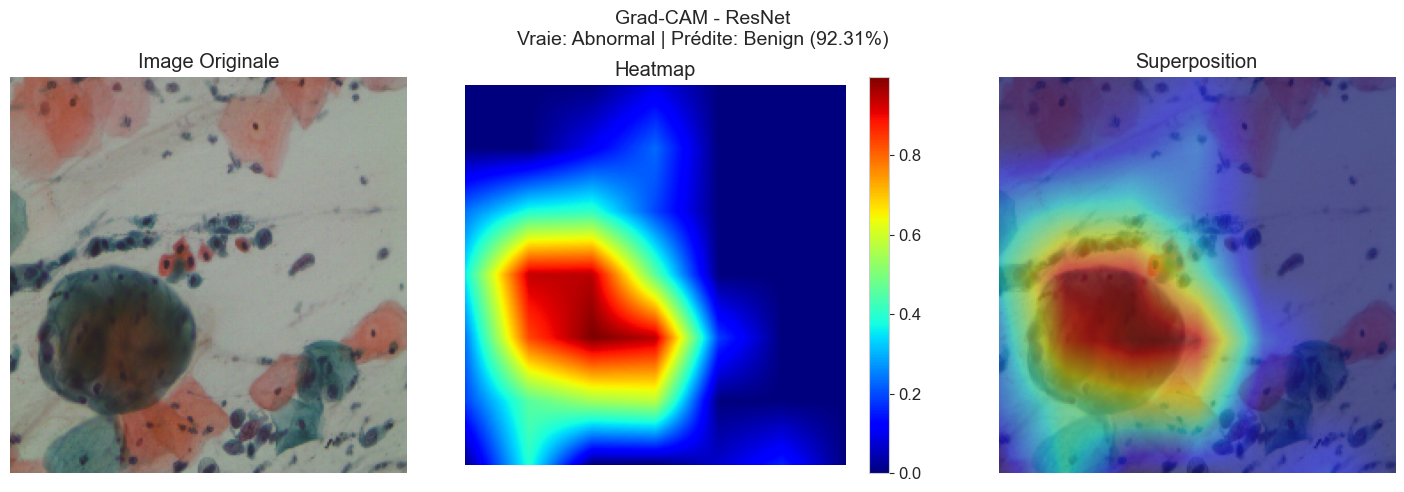


Analyse avec EfficientNet:


KeyboardInterrupt: 

In [20]:
print("\n" + "=" * 60)
print("IMPLÉMENTATION GRAD-CAM")
print("=" * 60)

class SimpleGradCAM:
    """Grad-CAM simplifié et robuste"""
    
    def __init__(self, model, layer_name=None):
        self.model = model
        
        # Trouver une couche convolutionnelle
        if layer_name is None:
            for layer in reversed(model.layers):
                if 'conv' in layer.name or 'activation' in layer.name:
                    layer_name = layer.name
                    break
        
        if layer_name is None:
            # Prendre l'avant-dernière couche
            layer_name = model.layers[-2].name
        
        self.layer_name = layer_name
        print(f"  Couche utilisée: {layer_name}")
        
        # Créer le modèle pour Grad-CAM
        self.grad_model = tf.keras.models.Model(
            inputs=[model.input],
            outputs=[model.get_layer(layer_name).output, model.output]
        )
    
    def compute_heatmap(self, image, class_idx=None):
        """Calculer la heatmap Grad-CAM"""
        # S'assurer que l'image est un tensor
        if not tf.is_tensor(image):
            image = tf.convert_to_tensor(image, dtype=tf.float32)
        
        if len(image.shape) == 3:
            image = tf.expand_dims(image, axis=0)
        
        with tf.GradientTape() as tape:
            tape.watch(image)
            conv_outputs, predictions = self.grad_model(image)
            
            if class_idx is None:
                class_idx = tf.argmax(predictions[0])
            
            loss = predictions[:, class_idx]
        
        # Calculer les gradients
        grads = tape.gradient(loss, conv_outputs)
        
        if grads is None:
            print("Gradients non calculés, retour heatmap vide")
            return np.zeros(conv_outputs.shape[1:3])
        
        # Moyenne des gradients
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        
        # Combinaison pondérée
        conv_outputs = conv_outputs[0]
        heatmap = tf.reduce_sum(pooled_grads * conv_outputs, axis=-1)
        
        # Normalisation
        heatmap = np.maximum(heatmap.numpy(), 0)
        if heatmap.max() > 0:
            heatmap = heatmap / heatmap.max()
        
        return heatmap
    
    def visualize_heatmap(self, image, heatmap, title="Grad-CAM"):
        """Visualiser la heatmap avec matplotlib"""
        from scipy.ndimage import zoom
        
        # Redimensionner la heatmap
        zoom_factors = (
            image.shape[0] / heatmap.shape[0],
            image.shape[1] / heatmap.shape[1]
        )
        heatmap_resized = zoom(heatmap, zoom_factors, order=1)
        
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # Image originale
        img_display = image.copy()
        if img_display.max() > 1.0:
            img_display = img_display / 255.0
        
        axes[0].imshow(img_display)
        axes[0].set_title("Image Originale")
        axes[0].axis('off')
        
        # Heatmap
        im = axes[1].imshow(heatmap_resized, cmap='jet')
        axes[1].set_title("Heatmap")
        axes[1].axis('off')
        plt.colorbar(im, ax=axes[1])
        
        # Superposition
        axes[2].imshow(img_display)
        axes[2].imshow(heatmap_resized, cmap='jet', alpha=0.5)
        axes[2].set_title("Superposition")
        axes[2].axis('off')
        
        plt.suptitle(title, fontsize=14)
        plt.tight_layout()
        
        return fig, heatmap_resized

# Initialiser les explainers Grad-CAM
gradcam_explainers = {}
for model_name, model in models.items():
    print(f"\nInitialisation Grad-CAM pour {model_name}...")
    try:
        explainer = SimpleGradCAM(model)
        gradcam_explainers[model_name] = explainer
        print(f"Grad-CAM initialisé pour {model_name}")
    except Exception as e:
        print(f"Erreur initialisation Grad-CAM {model_name}: {e}")

# Tester Grad-CAM sur une image
if len(TEST_IMAGES) > 0:
    print(f"\nTest Grad-CAM sur une image de test...")
    
    # Prendre la première image
    test_image = TEST_IMAGES[0]
    true_class = TRUE_CLASSES[0]
    
    for model_name, explainer in gradcam_explainers.items():
        print(f"\nAnalyse avec {model_name}:")
        
        # Calculer la prédiction
        model_prediction = models[model_name].predict(test_image[np.newaxis, ...])
        predicted_class = np.argmax(model_prediction[0])
        confidence = model_prediction[0][predicted_class]
        
        print(f"  Vraie classe: {CLASS_NAMES[true_class]}")
        print(f"  Prédiction: {CLASS_NAMES[predicted_class]} ({confidence:.2%})")
        
        # Calculer la heatmap
        heatmap = explainer.compute_heatmap(test_image)
        
        # Visualiser
        title = f"Grad-CAM - {model_name}\n"
        title += f"Vraie: {CLASS_NAMES[true_class]} | Prédite: {CLASS_NAMES[predicted_class]} ({confidence:.2%})"
        
        fig, _ = explainer.visualize_heatmap(test_image, heatmap, title=title)
        plt.show()
else:
    print("Aucune image disponible pour tester Grad-CAM!")

In [ ]:
# ============================================================================
# IMPORTANCE PAR GRADIENTS - VERSION SIMPLE
# ============================================================================
print("\n" + "=" * 60)
print("IMPORTANCE PAR GRADIENTS")
print("=" * 60)

class GradientImportance:
    """Calcul simple de l'importance via gradients"""
    
    def __init__(self, model):
        self.model = model
    
    def compute_importance(self, image):
        """Calculer l'importance des pixels via gradients"""
        # Convertir en tensor
        if not tf.is_tensor(image):
            image_tensor = tf.convert_to_tensor(image, dtype=tf.float32)
        else:
            image_tensor = image
        
        if len(image_tensor.shape) == 3:
            image_tensor = tf.expand_dims(image_tensor, axis=0)
        
        # Activer le gradient tracking
        image_tensor = tf.Variable(image_tensor)
        
        with tf.GradientTape() as tape:
            tape.watch(image_tensor)
            predictions = self.model(image_tensor)
            # Prendre la classe avec la plus haute probabilité
            pred_class = tf.argmax(predictions[0])
            loss = predictions[:, pred_class]
        
        # Calculer les gradients
        grads = tape.gradient(loss, image_tensor)
        
        if grads is not None:
            # Prendre la valeur absolue moyenne par canal
            importance = tf.reduce_mean(tf.abs(grads), axis=-1)
            return importance.numpy()[0]  # Retirer dimension batch
        else:
            print("Gradients non calculés, retour array zéro")
            return np.zeros(image.shape[:2])

# Initialiser les explainers d'importance
importance_explainers = {}
for model_name, model in models.items():
    print(f"\nInitialisation Gradient Importance pour {model_name}...")
    try:
        explainer = GradientImportance(model)
        importance_explainers[model_name] = explainer
        print(f"Gradient Importance initialisé pour {model_name}")
    except Exception as e:
        print(f"Erreur initialisation Gradient Importance {model_name}: {e}")


IMPORTANCE PAR GRADIENTS

Initialisation Gradient Importance pour ResNet...
Gradient Importance initialisé pour ResNet

Initialisation Gradient Importance pour EfficientNet...
Gradient Importance initialisé pour EfficientNet

Initialisation Gradient Importance pour MobileNet...
Gradient Importance initialisé pour MobileNet


In [ ]:
# ============================================================================
# IMPLÉMENTATION LIME ROBUSTE
# ============================================================================
print("\n" + "=" * 60)
print("IMPLÉMENTATION LIME")
print("=" * 60)

class RobustLIMEExplainer:
    """LIME avec gestion d'erreurs"""
    
    def __init__(self, model, class_names):
        self.model = model
        self.class_names = class_names
        self.explainer = lime_image.LimeImageExplainer()
    
    def predict_proba(self, images):
        """Fonction de prédiction pour LIME"""
        # LIME passe des images en float64, on convertit
        images = images.astype(np.float32)
        
        # Normaliser si nécessaire
        if images.max() > 1.0:
            images = images / 255.0
        
        return self.model.predict(images, verbose=0)
    
    def explain(self, image, top_labels=2, num_samples=200):
        """Générer une explication LIME (version légère)"""
        try:
            # Préparer l'image
            if len(image.shape) == 3:
                image_for_lime = image
            else:
                image_for_lime = image[0]
            
            # Normaliser pour LIME
            if image_for_lime.max() > 1.0:
                image_for_lime = image_for_lime / 255.0
            
            print(f"Calcul LIME ({num_samples} échantillons)...")
            
            explanation = self.explainer.explain_instance(
                image=image_for_lime,
                classifier_fn=self.predict_proba,
                top_labels=top_labels,
                hide_color=0,
                num_samples=num_samples  # Nombre réduit pour vitesse
            )
            
            # Prédiction
            preds = self.predict_proba(np.expand_dims(image_for_lime, axis=0))[0]
            pred_class = np.argmax(preds)
            
            return {
                'explanation': explanation,
                'predicted_class': pred_class,
                'class_name': self.class_names[pred_class],
                'confidence': preds[pred_class],
                'image': image_for_lime,
                'success': True
            }
            
        except Exception as e:
            print(f"Erreur LIME: {e}")
            return {
                'success': False,
                'error': str(e)
            }

# Initialiser les explainers LIME
lime_explainers = {}
for model_name, model in models.items():
    print(f"\n🔧 Initialisation LIME pour {model_name}...")
    try:
        explainer = RobustLIMEExplainer(model, CLASS_NAMES)
        lime_explainers[model_name] = explainer
        print(f"LIME initialisé pour {model_name}")
    except Exception as e:
        print(f"Erreur initialisation LIME {model_name}: {e}")


IMPLÉMENTATION LIME

🔧 Initialisation LIME pour ResNet...
LIME initialisé pour ResNet

🔧 Initialisation LIME pour EfficientNet...
LIME initialisé pour EfficientNet

🔧 Initialisation LIME pour MobileNet...
LIME initialisé pour MobileNet


# IMPORTANCE PAR GRADIENTS - VERSION SIMPLE



ANALYSE D'UNE IMAGE
Lancement de l'analyse pour tous les modèles...

Analyse avec ResNet:
  Prédit: Abnormal (0.879)
  Vérité: Abnormal
  Statut: CORRECT
Calcul Grad-CAM...


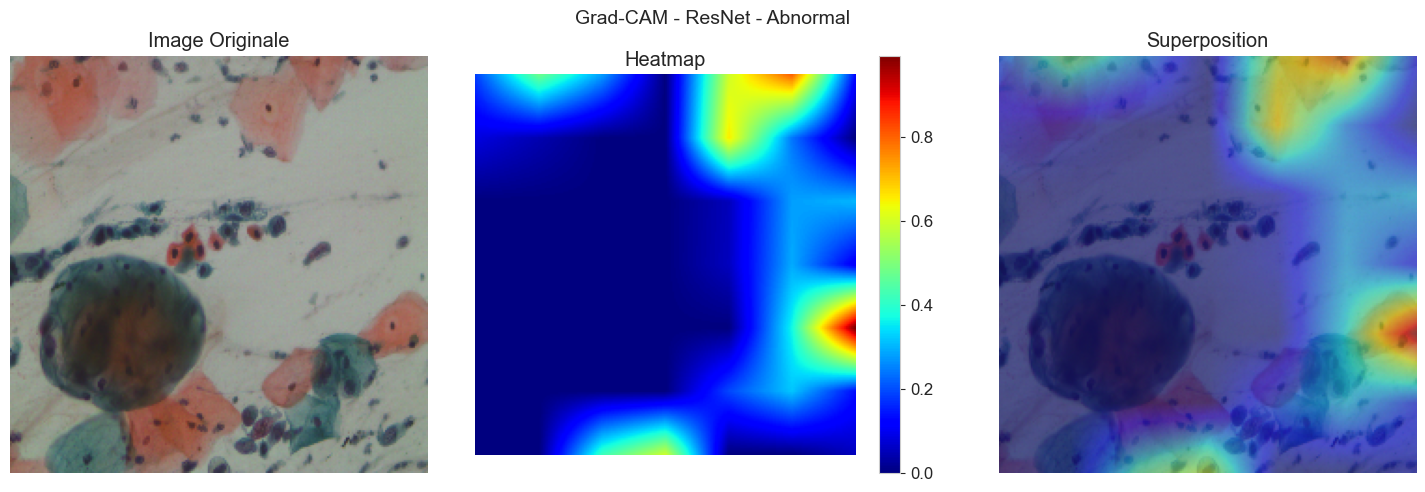

Calcul importance gradients...
Calcul LIME (léger)...
Calcul LIME (100 échantillons)...


100%|██████████| 100/100 [00:07<00:00, 12.79it/s]



Analyse avec EfficientNet:
  Prédit: Normal (0.394)
  Vérité: Abnormal
  Statut: INCORRECT
Calcul Grad-CAM...


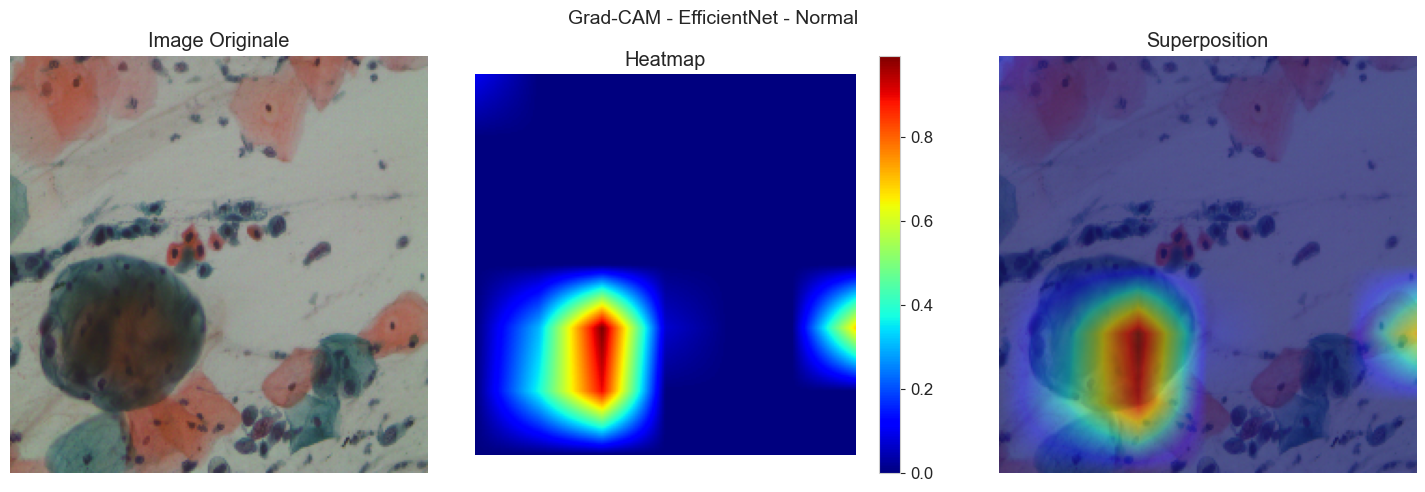

Calcul importance gradients...
Calcul LIME (léger)...
Calcul LIME (100 échantillons)...


100%|██████████| 100/100 [00:04<00:00, 22.13it/s]



Analyse avec MobileNet:
  Prédit: Benign (0.444)
  Vérité: Abnormal
  Statut: INCORRECT
Calcul Grad-CAM...


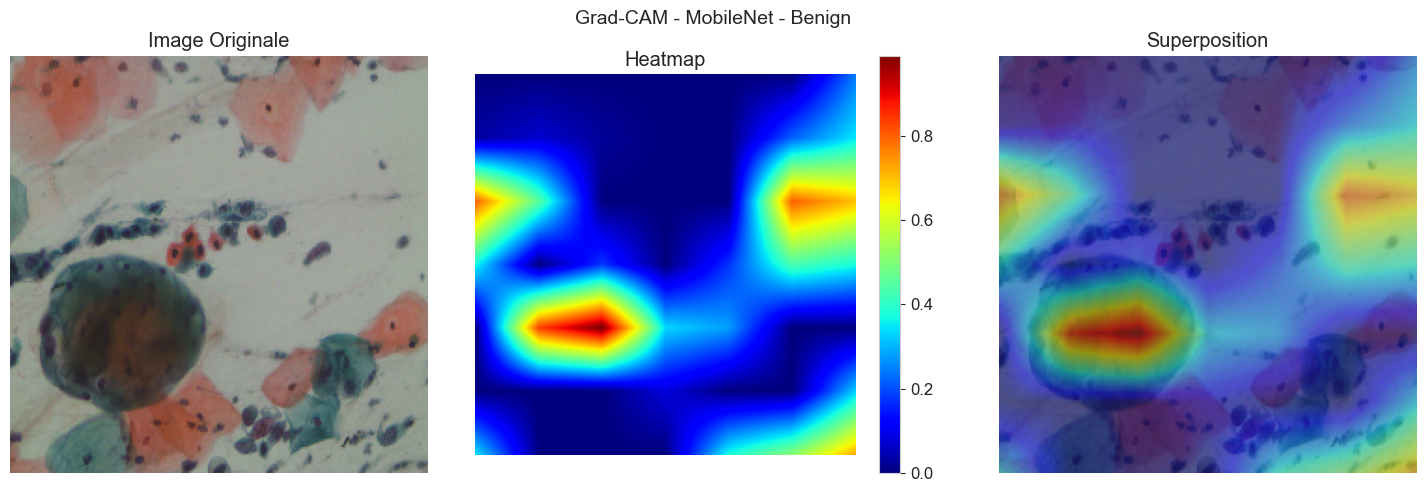

Calcul importance gradients...
Calcul LIME (léger)...
Calcul LIME (100 échantillons)...


 99%|█████████▉| 99/100 [00:04<00:00, 20.81it/s]


KeyboardInterrupt: 

In [ ]:
# ============================================================================
# ANALYSE D'UNE IMAGE - VERSION ULTRA ROBUSTE
# ============================================================================
print("\n" + "=" * 60)
print("ANALYSE D'UNE IMAGE")
print("=" * 60)

def analyze_single_image_safe(image, true_label_idx, image_idx=0, model_name=None):
    """Analyser une image avec un seul modèle (robuste)"""
    
    if model_name not in models:
        print(f"Modèle {model_name} non disponible")
        return None
    
    model = models[model_name]
    print(f"\nAnalyse avec {model_name}:")
    
    # Préparer l'image pour le modèle
    if len(image.shape) == 3:
        image_batch = np.expand_dims(image, axis=0)
    else:
        image_batch = image
    
    # Normaliser si nécessaire (pour modèles pré-entraînés)
    image_for_model = image_batch.copy()
    if image_for_model.max() > 1.0:
        image_for_model = image_for_model / 255.0
    
    # Prédiction
    try:
        prediction = model.predict(image_for_model, verbose=0)[0]
        pred_class_idx = np.argmax(prediction)
        confidence = prediction[pred_class_idx]
        
        print(f"  Prédit: {CLASS_NAMES[pred_class_idx]} ({confidence:.3f})")
        print(f"  Vérité: {CLASS_NAMES[true_label_idx]}")
        print(f"  Statut: {'CORRECT' if pred_class_idx == true_label_idx else 'INCORRECT'}")
        
    except Exception as e:
        print(f"Erreur prédiction: {e}")
        prediction = np.ones(len(CLASS_NAMES)) / len(CLASS_NAMES) 
        pred_class_idx = 0
        confidence = prediction[0]
    
    # Grad-CAM
    gradcam_result = None
    if model_name in gradcam_explainers:
        try:
            print("Calcul Grad-CAM...")
            gradcam = gradcam_explainers[model_name]
            heatmap = gradcam.compute_heatmap(image, pred_class_idx)
            fig_gradcam, heatmap_resized = gradcam.visualize_heatmap(
                image, heatmap, 
                title=f"Grad-CAM - {model_name} - {CLASS_NAMES[pred_class_idx]}"
            )
            plt.show()
            gradcam_result = {
                'heatmap': heatmap,
                'heatmap_resized': heatmap_resized,
                'figure': fig_gradcam
            }
        except Exception as e:
            print(f"Erreur Grad-CAM: {e}")
            gradcam_result = None
    
    # Importance par gradients
    importance_result = None
    if model_name in importance_explainers:
        try:
            print("Calcul importance gradients...")
            importance_exp = importance_explainers[model_name]
            importance_map = importance_exp.compute_importance(image)
            importance_result = importance_map
        except Exception as e:
            print(f"Erreur importance gradients: {e}")
            importance_result = None
    
    # LIME (optionnel)
    lime_result = None
    if model_name in lime_explainers:
        try:
            print("Calcul LIME (léger)...")
            lime_exp = lime_explainers[model_name]
            lime_result = lime_exp.explain(image, num_samples=100)  # Léger
        except Exception as e:
            print(f"Erreur LIME: {e}")
            lime_result = None
    
    # Résultats compilés
    results = {
        'model_name': model_name,
        'image': image,
        'true_label_idx': true_label_idx,
        'true_label': CLASS_NAMES[true_label_idx],
        'prediction': prediction,
        'pred_class_idx': pred_class_idx,
        'pred_class': CLASS_NAMES[pred_class_idx],
        'confidence': confidence,
        'is_correct': pred_class_idx == true_label_idx,
        'gradcam': gradcam_result,
        'importance': importance_result,
        'lime': lime_result
    }
    
    return results

# Analyser la première image avec tous les modèles
print("Lancement de l'analyse pour tous les modèles...")
true_label_idx = np.argmax(TEST_LABELS[0])
all_results = {}

for model_name in models.keys():
    results = analyze_single_image_safe(
        TEST_IMAGES[0], 
        true_label_idx, 
        image_idx=0, 
        model_name=model_name
    )
    if results is not None:
        all_results[model_name] = results

print(f"\nAnalyse terminée pour {len(all_results)} modèles")


VISUALISATION COMPARATIVE
Graphique sauvegardé: ../reports/explainability/comparison_simple_1.png


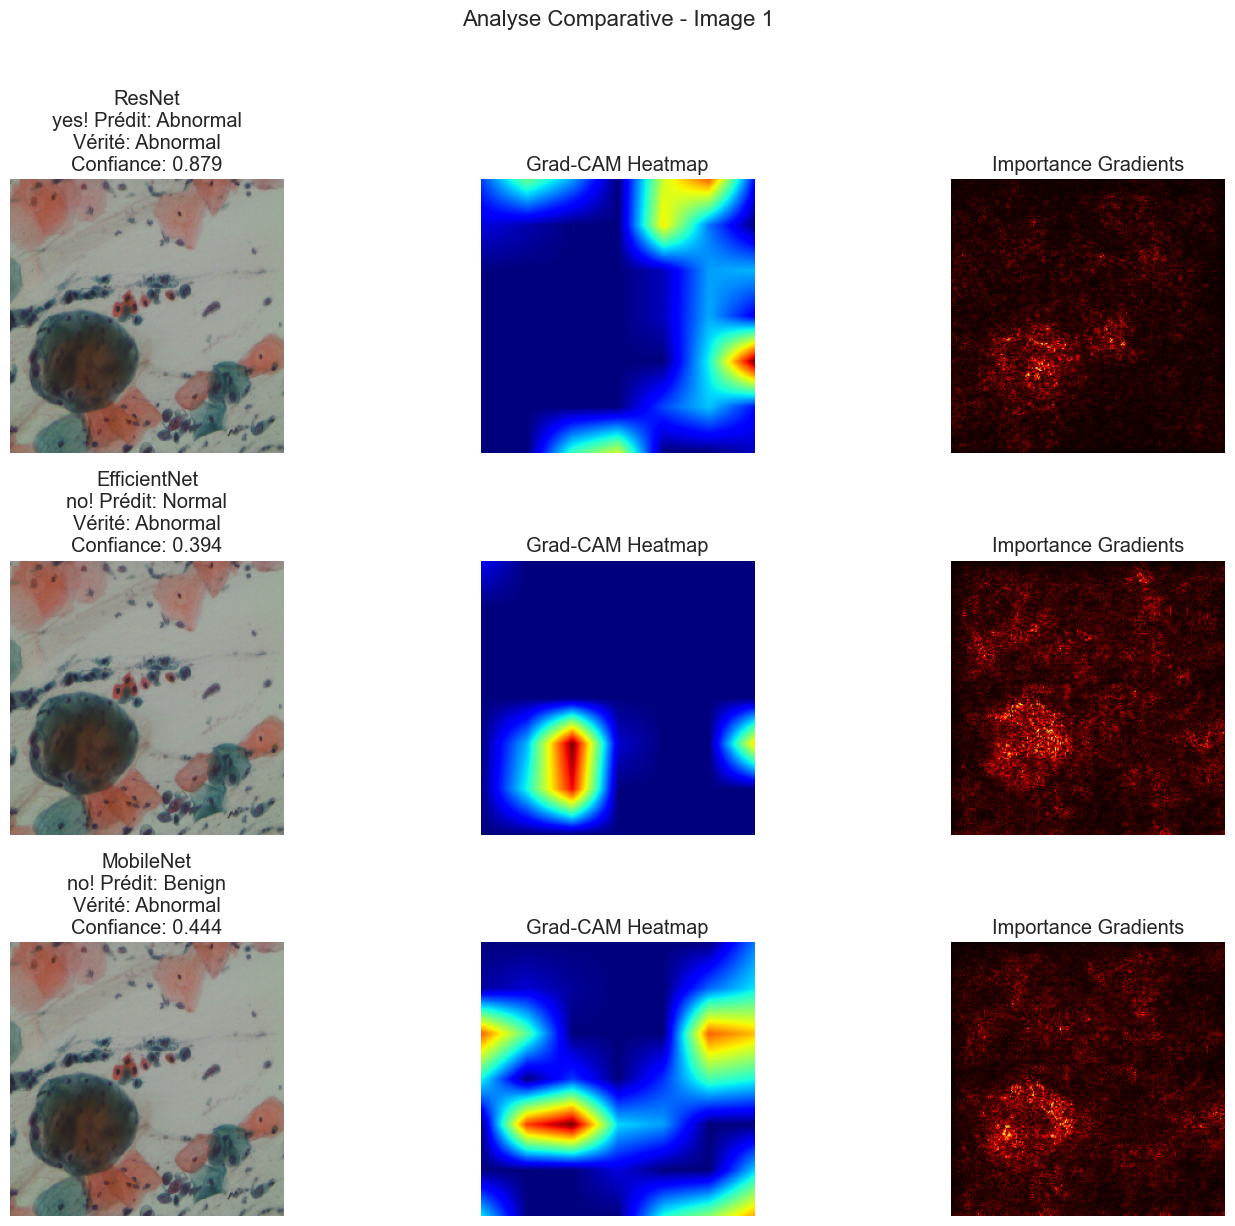

In [ ]:
# ============================================================================
# VISUALISATION COMPARATIVE SIMPLIFIÉE
# ============================================================================
print("\n" + "=" * 60)
print("VISUALISATION COMPARATIVE")
print("=" * 60)

def plot_simple_comparison(results_dict, image_idx=0):
    """Visualisation comparative simplifiée"""
    
    if not results_dict:
        print("Aucun résultat à visualiser")
        return
    
    model_names = list(results_dict.keys())
    n_models = len(model_names)
    
    fig, axes = plt.subplots(n_models, 3, figsize=(15, 4 * n_models))
    
    if n_models == 1:
        axes = np.expand_dims(axes, axis=0)
    
    for row_idx, model_name in enumerate(model_names):
        results = results_dict[model_name]
        image = results['image']
        
        # Normaliser l'image pour l'affichage
        img_display = image.copy()
        if img_display.max() > 1.0:
            img_display = img_display / 255.0
        
        # 1. Image originale avec prédiction
        axes[row_idx, 0].imshow(img_display)
        status = "yes!" if results['is_correct'] else "no!"
        axes[row_idx, 0].set_title(
            f"{model_name}\n"
            f"{status} Prédit: {results['pred_class']}\n"
            f"Vérité: {results['true_label']}\n"
            f"Confiance: {results['confidence']:.3f}"
        )
        axes[row_idx, 0].axis('off')
        
        # 2. Grad-CAM si disponible
        if results['gradcam'] is not None:
            heatmap = results['gradcam']['heatmap_resized']
            im = axes[row_idx, 1].imshow(heatmap, cmap='jet')
            axes[row_idx, 1].set_title('Grad-CAM Heatmap')
            axes[row_idx, 1].axis('off')
        else:
            axes[row_idx, 1].text(0.5, 0.5, "Grad-CAM\nnon disponible", 
                                 ha='center', va='center')
            axes[row_idx, 1].set_title('Grad-CAM')
            axes[row_idx, 1].axis('off')
        
        # 3. Importance gradients si disponible
        if results['importance'] is not None:
            im = axes[row_idx, 2].imshow(results['importance'], cmap='hot')
            axes[row_idx, 2].set_title('Importance Gradients')
            axes[row_idx, 2].axis('off')
        else:
            axes[row_idx, 2].text(0.5, 0.5, "Importance\nnon disponible", 
                                 ha='center', va='center')
            axes[row_idx, 2].set_title('Importance')
            axes[row_idx, 2].axis('off')
    
    plt.suptitle(f'Analyse Comparative - Image {image_idx+1}', fontsize=16, y=1.02)
    plt.tight_layout()
    
    # Sauvegarde
    os.makedirs('../reports/explainability', exist_ok=True)
    save_path = f'../reports/explainability/comparison_simple_{image_idx+1}.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"Graphique sauvegardé: {save_path}")
    
    plt.show()

# Générer la visualisation
if all_results:
    plot_simple_comparison(all_results, image_idx=0)
else:
    print("Aucun résultat à visualiser")

# VISUALISATION COMPARATIVE



VISUALISATION LIME
LIME ResNet sauvegardé: ../reports/explainability/lime_ResNet.png


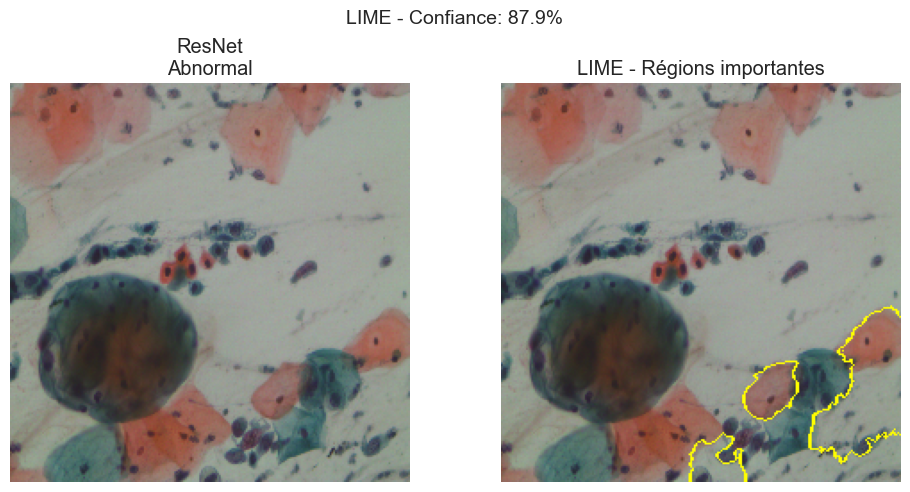

LIME EfficientNet sauvegardé: ../reports/explainability/lime_EfficientNet.png


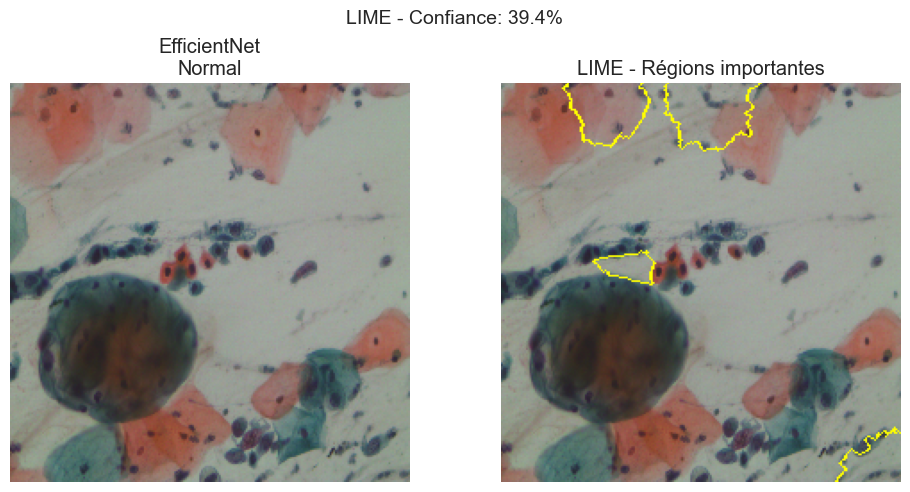

LIME MobileNet sauvegardé: ../reports/explainability/lime_MobileNet.png


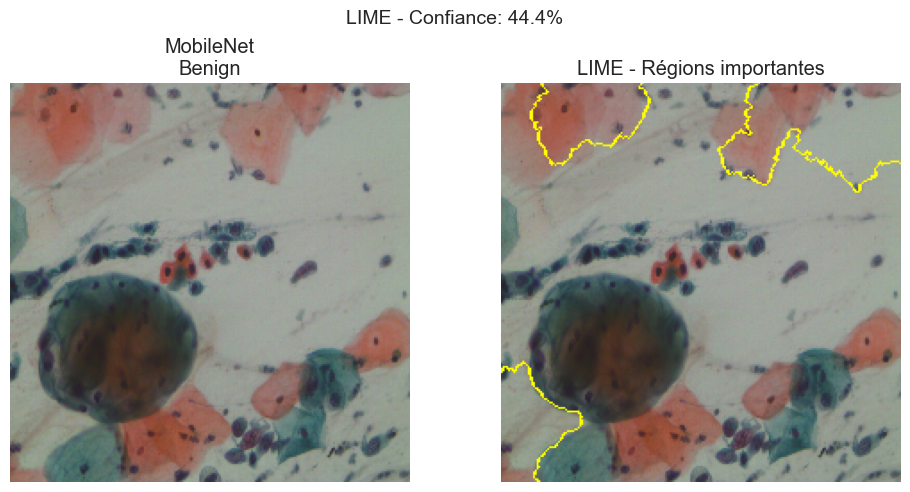

In [ ]:
# ============================================================================
# VISUALISATION LIME
# ============================================================================
print("\n" + "=" * 60)
print("VISUALISATION LIME")
print("=" * 60)

def plot_lime_if_available(results_dict):
    """Visualiser les résultats LIME s'ils existent"""
    
    for model_name, results in results_dict.items():
        if results['lime'] is not None and results['lime'].get('success', False):
            lime_result = results['lime']
            
            fig, axes = plt.subplots(1, 2, figsize=(10, 5))
            
            # Image originale
            axes[0].imshow(lime_result['image'])
            axes[0].set_title(f"{model_name}\n{lime_result['class_name']}")
            axes[0].axis('off')
            
            # Explication LIME
            try:
                explanation = lime_result['explanation']
                pred_class = lime_result['predicted_class']
                
                temp, mask = explanation.get_image_and_mask(
                    pred_class,
                    positive_only=True,
                    num_features=5,
                    hide_rest=False
                )
                axes[1].imshow(mark_boundaries(temp, mask))
                axes[1].set_title("LIME - Régions importantes")
            except:
                axes[1].text(0.5, 0.5, "Visualisation LIME\nnon disponible", 
                            ha='center', va='center')
            axes[1].axis('off')
            
            plt.suptitle(f"LIME - Confiance: {lime_result['confidence']:.1%}", 
                        fontsize=14)
            plt.tight_layout()
            
            # Sauvegarde
            save_path = f'../reports/explainability/lime_{model_name}.png'
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"LIME {model_name} sauvegardé: {save_path}")
            
            plt.show()
        else:
            print(f"Pas de résultat LIME pour {model_name}")

if all_results:
    plot_lime_if_available(all_results)


# streamlit

In [ ]:
import streamlit as st
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import sys
from pathlib import Path

In [ ]:
!pip install streamlit -q

# Configuration pour Jupyter
import sys
import os
from pathlib import Path

print("Streamlit prêt pour Jupyter")

Streamlit prêt pour Jupyter


In [ ]:
!pip install streamlit -q
!pip install streamlit-option-menu -q
!pip install plotly -q

print("Streamlit installé")

Streamlit installé


In [ ]:
# ============================================================================
# CHARGEMENT DES MODELES - KERAS 3 COMPATIBLE
# ============================================================================
print("\n" + "=" * 60)
print("CHARGEMENT DES MODELES")
print("=" * 60)

import tensorflow as tf
from pathlib import Path
import numpy as np

current_dir = Path.cwd()
models_dir = current_dir.parent / "src" / "models"

model_files = {
    "ResNet": ["resnet02.h5", "resnet02.keras", "resnet02_mlflow.h5"],
    "EfficientNet": ["efficientnet02.h5", "efficientnet02.keras", "eff02.h5"],
    "MobileNet": ["mobilenet01.h5", "mobilenet01.keras", "mobnet01.h5"]
}

# Initialize models dictionary
models_dict = {}  # Changed from 'models' to 'models_dict' to avoid confusion

print(f"Chargement de: {models_dir}")

for model_name, filenames in model_files.items():
    print(f"\n🔍 {model_name}:")
    
    for filename in filenames:
        filepath = models_dir / filename
        if filepath.exists():
            print(f"   Trying: {filename} ({filepath.stat().st_size:,} bytes)")
            
            try:
                model = tf.keras.models.load_model(str(filepath))
                models_dict[model_name] = model
                print(f"✅ Réussi!")
                print(f"   Input: {model.input_shape}")
                print(f"   Output: {model.output_shape}")
                break
            except Exception as e:
                print(f"❌ Echec: {str(e)[:80]}...")
    
    if model_name not in models_dict:
        print(f"⚠️  Impossible de charger {model_name}")

print(f"\nModèles chargés: {list(models_dict.keys())}")

# ============================================================================
# VÉRIFICATION ET PRÉDICTIONS
# ============================================================================
print("\n" + "=" * 60)
print("VÉRIFICATION DES MODÈLES CHARGÉS")
print("=" * 60)

# Use the actual loaded models dictionary
print(f"📊 Type de 'models_dict': {type(models_dict)}")
print(f"📊 Nombre de modèles: {len(models_dict)}")

if isinstance(models_dict, dict) and len(models_dict) > 0:
    print(f"✅ Modèles disponibles: {list(models_dict.keys())}")
    
    # Check each model
    for model_name, model in models_dict.items():
        print(f"\n🔍 {model_name}:")
        print(f"   Type: {type(model)}")
        print(f"   Input shape: {model.input_shape}")
        print(f"   Output shape: {model.output_shape}")
        print(f"   Nombre de couches: {len(model.layers)}")
        
        # Check if it's a valid Keras model
        if hasattr(model, 'predict'):
            print(f"   ✅ Méthode 'predict' disponible")
        else:
            print(f"   ❌ Pas de méthode 'predict'")
            
else:
    print(f"❌ Aucun modèle chargé")
    print(f"   Valeur de 'models_dict': {models_dict}")

# ============================================================================
# PRÉDICTIONS RÉELLES
# ============================================================================
print("\n" + "=" * 60)
print("📊 PRÉDICTIONS RÉELLES")
print("=" * 60)

if 'TEST_IMAGES' not in locals() and 'TEST_IMAGES' not in globals():
    print("⚠️  TEST_IMAGES non défini, création d'image factice...")
    # Create a dummy image based on model input shape
    if len(models_dict) > 0:
        sample_model = list(models_dict.values())[0]
        input_shape = sample_model.input_shape[1:]  # Remove batch dimension
        TEST_IMAGES = [np.random.randn(*input_shape).astype(np.float32)]
        TRUE_CLASSES = [0]
        CLASS_NAMES = [f"Class_{i}" for i in range(10)]  # Assuming 10 classes
        print(f"   Image factice créée avec shape: {TEST_IMAGES[0].shape}")
    else:
        TEST_IMAGES = []
        TRUE_CLASSES = []
        CLASS_NAMES = []

if isinstance(models_dict, dict) and len(models_dict) > 0 and len(TEST_IMAGES) > 0:
    # Take first test image
    test_image = TEST_IMAGES[0]
    true_class_idx = TRUE_CLASSES[0]
    true_class_name = CLASS_NAMES[true_class_idx]
    
    print(f"🔍 Analyse de l'image 1:")
    print(f"   Vraie classe: {true_class_name}")
    print(f"   Taille image: {test_image.shape}")
    print(f"   Valeurs min/max: {test_image.min():.3f}/{test_image.max():.3f}")
    
    # Prepare image for prediction (normalize if needed)
    if test_image.max() > 1.0:
        print(f"   Normalisation de l'image (division par 255)")
        test_image_normalized = test_image / 255.0
    else:
        test_image_normalized = test_image
    
    # Add batch dimension
    input_image = test_image_normalized[np.newaxis, ...]
    print(f"   Shape après ajout batch: {input_image.shape}")
    
    results = {
        "true_class": true_class_name,
        "true_class_index": int(true_class_idx),
        "image_shape": test_image.shape,
        "predictions": {}
    }
    
    print(f"\n📈 Prédictions:")
    
    for model_name, model in models_dict.items():  # Changed from models to models_dict
        print(f"\n🔬 {model_name}:")
        
        try:
            # Make prediction
            predictions = model.predict(input_image, verbose=0)
            print(f"   Shape des prédictions: {predictions.shape}")
            
            # Get results
            predicted_class_idx = np.argmax(predictions[0])
            confidence = float(predictions[0][predicted_class_idx])
            predicted_class_name = CLASS_NAMES[predicted_class_idx]
            is_correct = (predicted_class_idx == true_class_idx)
            
            # Store results
            results["predictions"][model_name] = {
                "predicted_class": predicted_class_name,
                "predicted_class_index": int(predicted_class_idx),
                "confidence": confidence,
                "confidence_percentage": f"{confidence:.1%}",
                "is_correct": bool(is_correct),
                "all_probabilities": predictions[0].tolist()
            }
            
            # Display
            status = "✅" if is_correct else "❌"
            print(f"   {status} Prédit: {predicted_class_name}")
            print(f"   Confiance: {confidence:.1%}")
            
            # Show all probabilities
            print(f"   Détail des probabilités:")
            for idx, prob in enumerate(predictions[0]):
                class_name = CLASS_NAMES[idx]
                marker = " ←" if idx == predicted_class_idx else ""
                print(f"     {class_name}: {prob:.1%}{marker}")
                
        except Exception as e:
            print(f"   ❌ Erreur: {str(e)[:100]}")
            import traceback
            print(f"   Détail: {traceback.format_exc()[:200]}...")
            
            results["predictions"][model_name] = {
                "error": str(e),
                "traceback": traceback.format_exc()
            }
    
    # Calculate statistics
    total_models = len(models_dict)
    correct_predictions = sum(1 for pred in results["predictions"].values() 
                            if isinstance(pred, dict) and pred.get("is_correct", False))
    accuracy = (correct_predictions / total_models * 100) if total_models > 0 else 0
    
    print(f"\n📊 RÉSUMÉ:")
    print(f"   Modèles testés: {total_models}")
    print(f"   Prédictions correctes: {correct_predictions}")
    print(f"   Précision: {accuracy:.1f}%")
    
    # Save results
    import json
    from datetime import datetime
    from pathlib import Path
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    reports_dir = current_dir / "reports" / "predictions"
    reports_dir.mkdir(parents=True, exist_ok=True)
        
    # Create the results file path
    results_file = reports_dir / f"predictions_real_{timestamp}.json"
        
    with open(results_file, 'w', encoding='utf-8') as f:
        json.dump(results, f, indent=2, ensure_ascii=False)
        
    print(f"\n💾 Résultats sauvegardés: {results_file}")
    
else:
    print(f"❌ Impossible de faire des prédictions")
    if not isinstance(models_dict, dict) or len(models_dict) == 0:
        print(f"   Raison: Aucun modèle chargé")
    if len(TEST_IMAGES) == 0:
        print(f"   Raison: Aucune image de test")


CHARGEMENT DES MODELES
Chargement de: c:\Users\sarah\Documents\M Info\M2 SID\AASD\Apprentisaage\src\models

🔍 ResNet:
   Trying: resnet02.h5 (101,263,416 bytes)


✅ Réussi!
   Input: (None, 224, 224, 3)
   Output: (None, 3)

🔍 EfficientNet:
   Trying: efficientnet02.h5 (800 bytes)
❌ Echec: No model config found in the file at c:\Users\sarah\Documents\M Info\M2 SID\AASD...
   Trying: efficientnet02.keras (24,946,174 bytes)
✅ Réussi!
   Input: (None, 224, 224, 3)
   Output: (None, 3)

🔍 MobileNet:
   Trying: mobilenet01.h5 (800 bytes)
❌ Echec: No model config found in the file at c:\Users\sarah\Documents\M Info\M2 SID\AASD...
   Trying: mobilenet01.keras (20,993,534 bytes)
✅ Réussi!
   Input: (None, 224, 224, 3)
   Output: (None, 3)

Modèles chargés: ['ResNet', 'EfficientNet', 'MobileNet']

VÉRIFICATION DES MODÈLES CHARGÉS
📊 Type de 'models_dict': <class 'dict'>
📊 Nombre de modèles: 3
✅ Modèles disponibles: ['ResNet', 'EfficientNet', 'MobileNet']

🔍 ResNet:
   Type: <class 'keras.src.models.functional.Functional'>
   Input shape: (None, 224, 224, 3)
   Output shape: (None, 3)
   Nombre de couches: 180
   ✅ Méthode 'predict' disponible

🔍 Efficient

In [ ]:
class GradCAMExplainer:
    """Grad-CAM pour CNN"""
    
    def __init__(self, model):
        self.model = model
        self.layer_name = self._find_target_layer()
        
    def _find_target_layer(self):
        for layer in reversed(self.model.layers):
            if 'conv' in layer.name or 'activation' in layer.name:
                return layer.name
        return self.model.layers[-2].name
    
    def compute_heatmap(self, image, class_idx=None):
        if len(image.shape) == 3:
            image = np.expand_dims(image, axis=0)
        
        grad_model = tf.keras.models.Model(
            inputs=[self.model.input],
            outputs=[self.model.get_layer(self.layer_name).output, self.model.output]
        )
        
        with tf.GradientTape() as tape:
            conv_outputs, predictions = grad_model(image)
            if class_idx is None:
                class_idx = tf.argmax(predictions[0])
            loss = predictions[:, class_idx]
        
        grads = tape.gradient(loss, conv_outputs)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        
        conv_outputs = conv_outputs[0]
        heatmap = tf.reduce_sum(pooled_grads * conv_outputs, axis=-1)
        
        heatmap = np.maximum(heatmap.numpy(), 0)
        heatmap = heatmap / (heatmap.max() + 1e-10)
        
        return heatmap

# Initialiser
gradcam_explainers = {name: GradCAMExplainer(model) for name, model in models_dict.items()}
print("✅ Grad-CAM initialisé pour tous les modèles")

✅ Grad-CAM initialisé pour tous les modèles


In [ ]:
image = TEST_IMAGES[0]
true_label_idx = np.argmax(TEST_LABELS[0])

print("="*60)
print(f"🔍 ANALYSE DE L'IMAGE 1")
print(f"Vérité terrain: {CLASS_NAMES[true_label_idx]}")
print("="*60)

results = {}

for model_name, model in models_dict.items():
    print(f"\n📊 {model_name}:")
    
    # Prédiction
    img_batch = np.expand_dims(image / 255.0, axis=0)
    prediction = model.predict(img_batch, verbose=0)[0]
    pred_class_idx = np.argmax(prediction)
    confidence = prediction[pred_class_idx]
    
    print(f"  Prédit: {CLASS_NAMES[pred_class_idx]} ({confidence:.3f})")
    print(f"  Statut: {'✅ CORRECT' if pred_class_idx == true_label_idx else '❌ INCORRECT'}")
    
    # Grad-CAM
    heatmap = gradcam_explainers[model_name].compute_heatmap(image, pred_class_idx)
    
    # Stocker
    results[model_name] = {
        'prediction': prediction,
        'pred_class_idx': pred_class_idx,
        'confidence': confidence,
        'is_correct': pred_class_idx == true_label_idx,
        'heatmap': heatmap
    }

🔍 ANALYSE DE L'IMAGE 1
Vérité terrain: Abnormal

📊 ResNet:
  Prédit: Abnormal (0.879)
  Statut: ✅ CORRECT

📊 EfficientNet:
  Prédit: Normal (0.394)
  Statut: ❌ INCORRECT

📊 MobileNet:
  Prédit: Benign (0.444)
  Statut: ❌ INCORRECT



🖼️ VISUALISATION COMPARATIVE
📁 Visualisation sauvegardée: ../reports/explainability/comparison.png


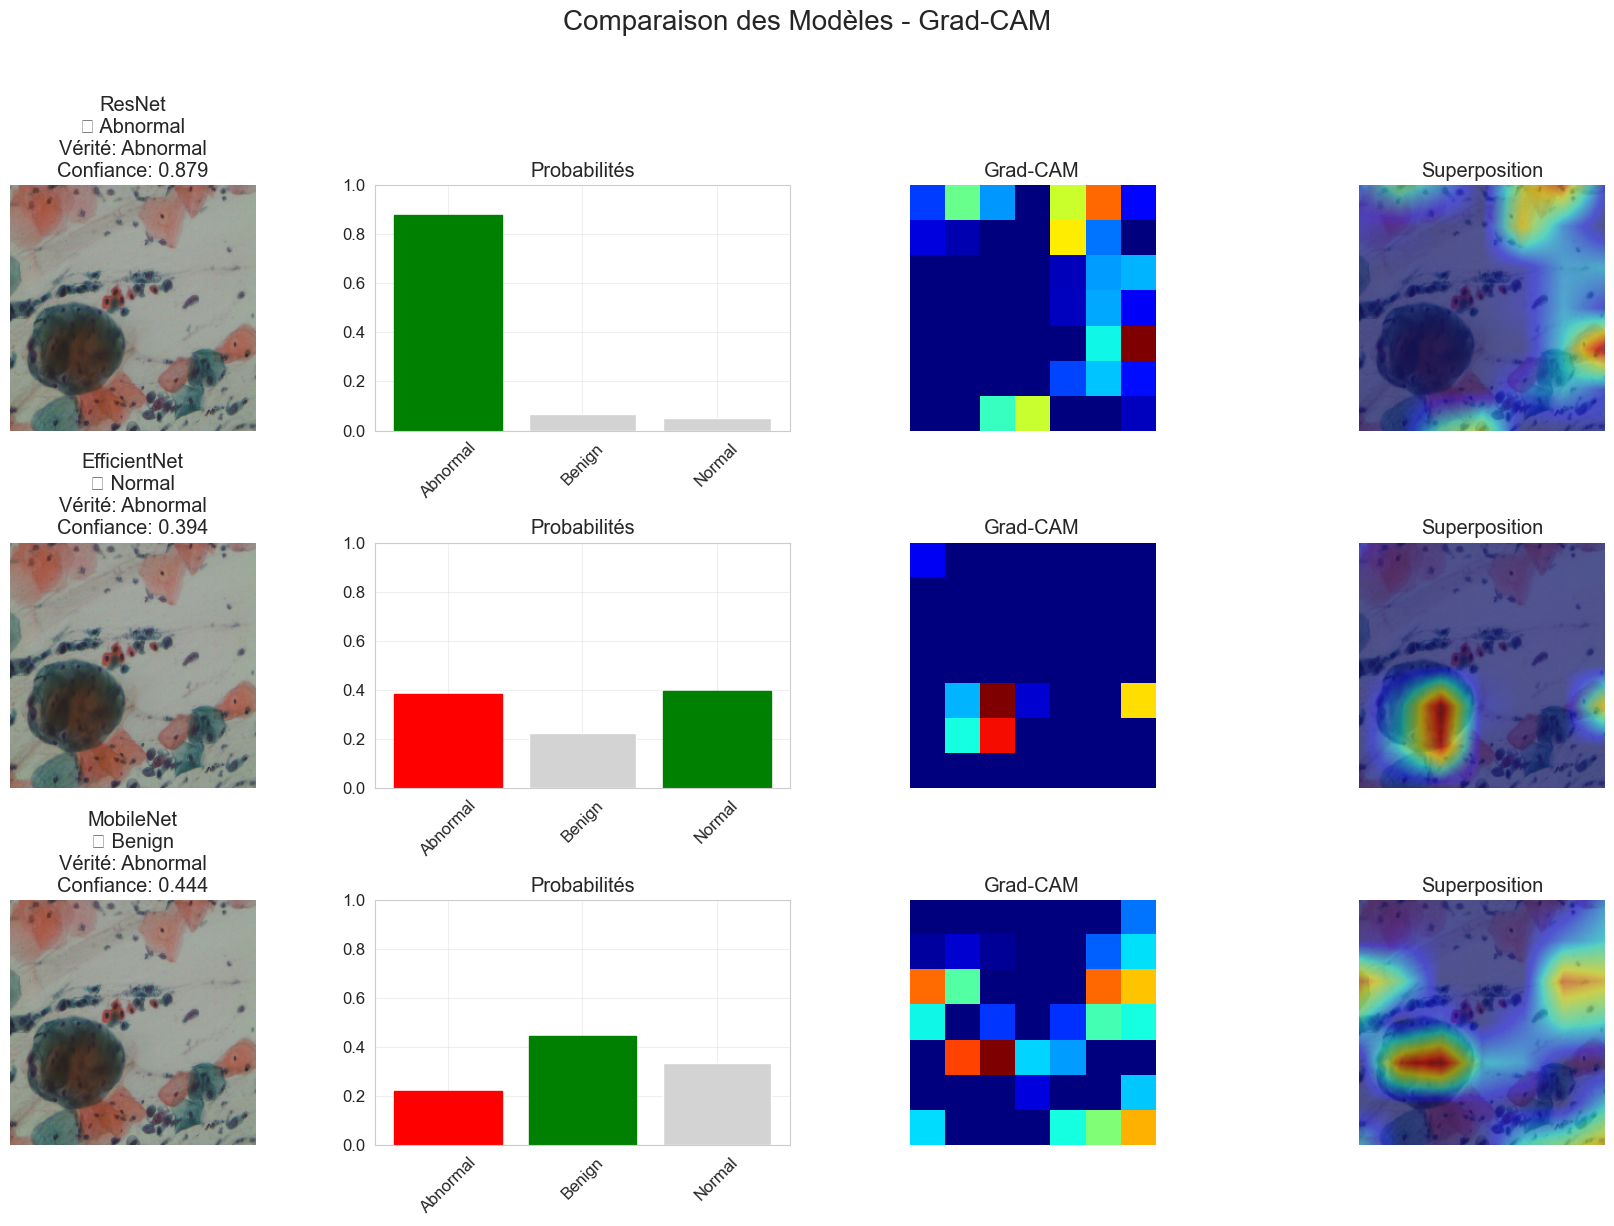

In [ ]:
print("\n" + "="*60)
print("🖼️ VISUALISATION COMPARATIVE")
print("="*60)

# Créer une figure
fig, axes = plt.subplots(3, 4, figsize=(18, 12))

model_names = list(results.keys())

for row_idx, model_name in enumerate(model_names):
    model_results = results[model_name]
    
    # Image originale
    axes[row_idx, 0].imshow(image / 255.0)
    status = "✅" if model_results['is_correct'] else "❌"
    axes[row_idx, 0].set_title(
        f"{model_name}\n{status} {CLASS_NAMES[model_results['pred_class_idx']]}\n"
        f"Vérité: {CLASS_NAMES[true_label_idx]}\n"
        f"Confiance: {model_results['confidence']:.3f}"
    )
    axes[row_idx, 0].axis('off')
    
    # Distribution des probabilités
    probs = model_results['prediction']
    bars = axes[row_idx, 1].bar(range(len(probs)), probs, color=['lightgray']*len(probs))
    bars[model_results['pred_class_idx']].set_color('green')
    if model_results['pred_class_idx'] != true_label_idx:
        bars[true_label_idx].set_color('red')
    
    axes[row_idx, 1].set_xticks(range(len(probs)))
    axes[row_idx, 1].set_xticklabels(CLASS_NAMES, rotation=45)
    axes[row_idx, 1].set_ylim([0, 1])
    axes[row_idx, 1].set_title('Probabilités')
    axes[row_idx, 1].grid(True, alpha=0.3)
    
    # Heatmap Grad-CAM
    heatmap = model_results['heatmap']
    im = axes[row_idx, 2].imshow(heatmap, cmap='jet')
    axes[row_idx, 2].set_title('Grad-CAM')
    axes[row_idx, 2].axis('off')
    
    # Superposition
    from scipy.ndimage import zoom
    zoom_factors = (image.shape[0]/heatmap.shape[0], image.shape[1]/heatmap.shape[1])
    heatmap_resized = zoom(heatmap, zoom_factors, order=1)
    
    axes[row_idx, 3].imshow(image / 255.0)
    axes[row_idx, 3].imshow(heatmap_resized, cmap='jet', alpha=0.5)
    axes[row_idx, 3].set_title('Superposition')
    axes[row_idx, 3].axis('off')

plt.suptitle('Comparaison des Modèles - Grad-CAM', fontsize=20, y=1.02)
plt.tight_layout()

# Sauvegarder
import os
os.makedirs('../reports/explainability', exist_ok=True)
plt.savefig('../reports/explainability/comparison.png', dpi=150, bbox_inches='tight')
print("📁 Visualisation sauvegardée: ../reports/explainability/comparison.png")

plt.show()


📊 RÉSUMÉ STATISTIQUE

📈 PERFORMANCES :
  Exactitude globale: 33.3%
  Correct: 1/3

🔍 DÉTAILS PAR MODÈLE :
  ✅ ResNet          Abnormal   (87.9%)
  ❌ EfficientNet    Normal     (39.4%)
  ❌ MobileNet       Benign     (44.4%)

🎯 ANALYSE DES ERREURS :
  • EfficientNet: Confusion Normal ↔ Abnormal
  • MobileNet: Confusion Benign ↔ Abnormal


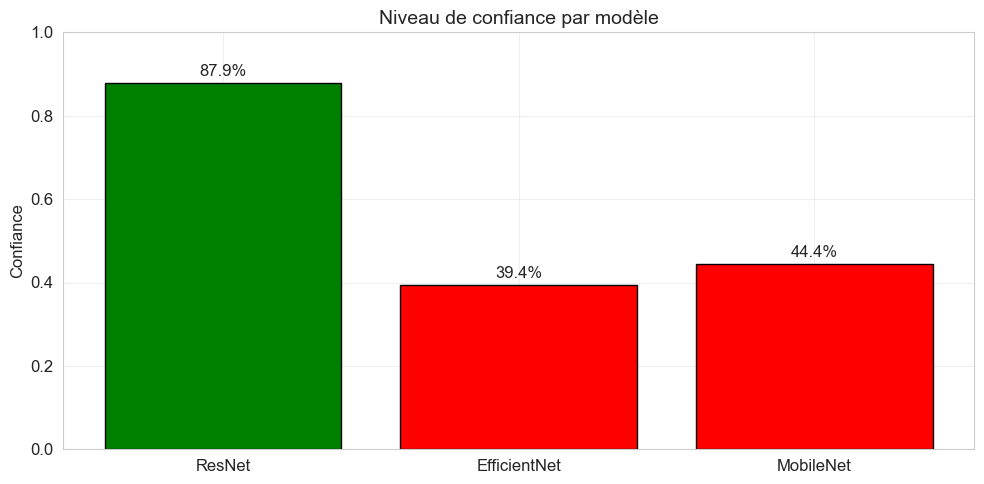

In [ ]:
print("\n" + "="*60)
print("📊 RÉSUMÉ STATISTIQUE")
print("="*60)

# Calculer les métriques
correct_count = sum(1 for r in results.values() if r['is_correct'])
accuracy = (correct_count / len(results)) * 100

print(f"\n📈 PERFORMANCES :")
print(f"  Exactitude globale: {accuracy:.1f}%")
print(f"  Correct: {correct_count}/{len(results)}")

print(f"\n🔍 DÉTAILS PAR MODÈLE :")
for model_name, model_results in results.items():
    status = "✅" if model_results['is_correct'] else "❌"
    print(f"  {status} {model_name:15} {CLASS_NAMES[model_results['pred_class_idx']]:10} "
          f"({model_results['confidence']:.1%})")

print(f"\n🎯 ANALYSE DES ERREURS :")
for model_name, model_results in results.items():
    if not model_results['is_correct']:
        print(f"  • {model_name}: Confusion {CLASS_NAMES[model_results['pred_class_idx']]} ↔ {CLASS_NAMES[true_label_idx]}")

# Graphique des confiances
fig, ax = plt.subplots(figsize=(10, 5))
models_list = list(results.keys())
confidences = [results[m]['confidence'] for m in models_list]
colors = ['green' if results[m]['is_correct'] else 'red' for m in models_list]

bars = ax.bar(models_list, confidences, color=colors, edgecolor='black')
ax.set_ylabel('Confiance')
ax.set_ylim([0, 1])
ax.set_title('Niveau de confiance par modèle', fontsize=14)
ax.grid(True, alpha=0.3)

# Ajouter les valeurs
for bar, conf in zip(bars, confidences):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
           f'{conf:.1%}', ha='center', va='bottom')

plt.tight_layout()
plt.show()